In [13]:
from pathlib import Path
from PIL import Image

import pandas as pd
import random
import matplotlib.pyplot as plt
import shutil
import os
import json
import splitfolders

import hashlib
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

In [37]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "cnn_svm":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATASET_TRAIN = PROJECT_DIR/ "dataset" / "raw"  / "Dataset" / "GCD" / "train" 
DATASET_TEST = PROJECT_DIR / "dataset" / "raw"  / "Dataset" / "GCD" / "test" 



OUTPUT_DIR = CURRENT_DIR / "dataset"
TRAIN_DIR = OUTPUT_DIR / "train"
VAL_DIR = OUTPUT_DIR / "val"

LOG_DIR = CURRENT_DIR / "logs" 
CONFIG_PATH = LOG_DIR / "data_augmentation_config.json"


assert DATASET_TRAIN.exists(), (
    f"Folder TRAIN tidak ditemukan:\n{DATASET_TRAIN}\n"
    "Pastikan notebook dijalankan dari root cloud-classification."
)

assert DATASET_TEST.exists(), (
    f"Folder TEST tidak ditemukan:\n{DATASET_TEST}\n"
    "Pastikan notebook dijalankan dari root cloud-classification."
)

# Tidak ada target atau batas jumlah citra per kelas.
SEED = 42
VAL_RATIO = 0.10
IMAGE_SIZE = (224, 224)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

AUGMENTATION_LABELS = ("b)", "c)", "d)", "e)", "f)", "g)", "h)")
AUGMENTATION_PARAMS = {
    "shift_y": 100,
    "shift_x": 250,
    "rotation_degrees": 4,
    "saturation_factor": 1.5,
    "contrast_factor": 1.5,
    "brightness_factor": 1.1,
    "sharpness_factor": 1.05,
    "jpeg_quality": 95,
}

LOG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
class_directories = sorted(path for path in DATASET_TRAIN.iterdir() if path.is_dir())
class_names = [path.name for path in class_directories]
test_class_names = sorted(path.name for path in DATASET_TEST.iterdir() if path.is_dir())
if not class_names or class_names != test_class_names:
    raise ValueError("Folder kelas train dan test asli harus tersedia dan sama.")

In [18]:
split_rng = random.Random(SEED)
split_records = []
originals_by_split = {split: {} for split in ("train", "val", "test")}
original_sources = {}

In [25]:
def list_images(directory):
    """Mengambil citra secara terurut; file JSON/CSV tidak ikut dihitung."""
    return sorted(
        path for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

def augmentation_path(source_path, label):
    """Nama tetap membuat pengulangan tidak menambah salinan baru."""
    return source_path.with_name(f"{source_path.name}__aug_{label[0]}.jpg")

def file_sha256(path):
    """Memeriksa kesamaan isi file, bukan hanya kesamaan nama."""
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

In [20]:
for class_directory in class_directories:
        class_name = class_directory.name
        files = list_images(class_directory)

        split_rng.shuffle(files)
        val_count = max(1, int(len(files) * VAL_RATIO))
        split_files = {
                "train": files[val_count:],
                "val": files[:val_count],
                "test": list_images(DATASET_TEST / class_name),
        }
        if not split_files["test"]:
                raise ValueError(f"Test asli untuk kelas {class_name} kosong.")

        for split, source_paths in split_files.items():
                originals_by_split[split][class_name] = []
                raw_class_dir = (DATASET_TEST if split == "test" else DATASET_TRAIN) / class_name
                for raw_path in sorted(source_paths):
                        destination = OUTPUT_DIR / split / class_name / raw_path.relative_to(raw_class_dir)
                        originals_by_split[split][class_name].append(destination)
                        original_sources[destination] = raw_path
                        split_records.append({
                        "split": split,
                        "kelas": class_name,
                        "sumber_asli": raw_path.relative_to(PROJECT_DIR).as_posix(),
                        "tujuan": destination.relative_to(PROJECT_DIR).as_posix(),
                        })
# Sumber augmentasi selalu berasal dari indeks citra train asli ini.
train_originals = originals_by_split["train"]
expected_original_paths = set(original_sources)
expected_augmented_paths = {
        augmentation_path(path, label)
        for paths in train_originals.values()
        for path in paths
        for label in AUGMENTATION_LABELS
}
expected_augmented_count = sum(map(len, train_originals.values())) * len(AUGMENTATION_LABELS)
if expected_original_paths & expected_augmented_paths or len(expected_augmented_paths) != expected_augmented_count:
        raise RuntimeError("Nama hasil augmentasi bertabrakan dengan file lain.")

# Catat konfigurasi agar pengulangan tidak mencampur split atau transformasi berbeda.
config_record = {
        "pipeline_version": 2,
        "seed": SEED,
        "val_ratio": VAL_RATIO,
        "image_size": list(IMAGE_SIZE),
        "augmentation_labels": list(AUGMENTATION_LABELS),
        "augmentation_parameters": AUGMENTATION_PARAMS,
        "split_signature": hashlib.sha256(
                json.dumps(split_records, sort_keys=True).encode("utf-8")
        ).hexdigest(),
}

existing_paths = set(list_images(OUTPUT_DIR))
unexpected_paths = existing_paths - expected_original_paths - expected_augmented_paths

In [21]:
if unexpected_paths:
    examples = "\n".join(str(path) for path in sorted(unexpected_paths)[:5])
    raise RuntimeError(
        "dataset/source berisi citra di luar rencana split/augmentasi ini. "
        "Periksa dan pindahkan hasil eksperimen lama secara manual sebelum melanjutkan. "
        "Jangan menghapus dataset/raw. Contoh file yang perlu diperiksa:\n" + examples
    )

In [26]:
if CONFIG_PATH.exists():
    previous_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
    if previous_config != config_record:
        raise RuntimeError(
            "Konfigurasi atau daftar data berbeda dari proses sebelumnya. "
            "Arsipkan keluaran eksperimen lama beserta data_augmentation_config.json "
            "sebelum menjalankan konfigurasi baru."
        )
elif existing_paths & expected_augmented_paths:
    raise RuntimeError("Ada hasil augmentasi tanpa catatan konfigurasi; periksa file tersebut dahulu.")

In [30]:
#Verifikasi salinan yang sudah ada sebelum menulis file apa pun.
raw_hashes = {}
for destination, raw_path in original_sources.items():
    raw_hashes[raw_path] = file_sha256(raw_path)
    if destination.exists() and file_sha256(destination) != raw_hashes[raw_path]:
        raise RuntimeError(f"Salinan berbeda dari citra asli: {destination}")

In [38]:
LOG_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_PATH.write_text(json.dumps(config_record, indent=2), encoding="utf-8")

535

In [39]:
# Hanya menyalin dari raw ke source; file asli tidak ditulis ulang.
for destination, raw_path in original_sources.items():
    destination.parent.mkdir(parents=True, exist_ok=True)
    if not destination.exists():
        shutil.copy2(raw_path, destination)

In [40]:
split_df = pd.DataFrame(split_records)
split_df.to_csv(LOG_DIR / "data_augmentation_split.csv", index=False)
for class_name in class_names:
    counts = {split: len(originals_by_split[split][class_name]) for split in originals_by_split}
    print(f"{class_name}: train={counts['train']}, val={counts['val']}, test={counts['test']}")
print("Split selesai. Test merupakan salinan lengkap dari test resmi GCD.")

1_cumulus: train=698, val=77, test=750
2_altocumulus: train=653, val=72, test=750
3_cirrus: train=1038, val=115, test=753
4_clearsky: train=1935, val=215, test=1589
5_stratocumulus: train=1662, val=184, test=1790
6_cumulonimbus: train=2703, val=300, test=2761
7_mixed: train=314, val=34, test=607
Split selesai. Test merupakan salinan lengkap dari test resmi GCD.


In [41]:
data_folder = []
for class_name in class_names:
    n_train = len(train_originals[class_name])
    n_val = len(originals_by_split["val"][class_name])
    n_test = len(originals_by_split["test"][class_name])
    data_folder.append({
        "Nama Kelas": class_name,
        "Train Mentah": n_train + n_val,
        "Train Asli": n_train,
        "Validation": n_val,
        "Test Resmi": n_test,
    })

df_jumlah_file = pd.DataFrame(data_folder)
jumlah_file_train = int(df_jumlah_file["Train Asli"].sum())
jumlah_file_val = int(df_jumlah_file["Validation"].sum())
jumlah_file_test = int(df_jumlah_file["Test Resmi"].sum())
jumlah_file_before_split = jumlah_file_train + jumlah_file_val
display(df_jumlah_file)
print(f"Total train asli: {jumlah_file_train:,}")
print(f"Total validation: {jumlah_file_val:,}")
print(f"Total test resmi: {jumlah_file_test:,}")

,Nama Kelas,Train Mentah,Train Asli,Validation,Test Resmi
0,1_cumulus,775,698,77,750
1,2_altocumulus,725,653,72,750
2,3_cirrus,1153,1038,115,753
3,4_clearsky,2150,1935,215,1589
4,5_stratocumulus,1846,1662,184,1790
5,6_cumulonimbus,3003,2703,300,2761
6,7_mixed,348,314,34,607


Total train asli: 9,003
Total validation: 997
Total test resmi: 9,000


In [42]:
# Metadata dan tabel dataset disimpan di dataset/processed.
log_summary = {
    "train_asli": jumlah_file_train,
    "validation": jumlah_file_val,
    "test_resmi": jumlah_file_test,
    "total_sebelum_augmentasi": jumlah_file_train + jumlah_file_val + jumlah_file_test,
}
json_log_data = {"summary": log_summary, "per_kelas": data_folder}
with (LOG_DIR / "dataset_sebelum_augmentasi.json").open("w", encoding="utf-8") as handle:
    json.dump(json_log_data, handle, indent=2, ensure_ascii=False)
df_jumlah_file.to_csv(LOG_DIR / "dataset_sebelum_augmentasi.csv", index=False)
print("Ringkasan citra asli berhasil disimpan.")

Ringkasan citra asli berhasil disimpan.


In [43]:
# Pratinjau hanya memakai citra train asli; seed terpisah tidak mengubah split.
sample_rng = random.Random(SEED)
sample_images = {
    class_name: sample_rng.choice(paths)
    for class_name, paths in train_originals.items()
}
print(f"Jumlah kelas ditemukan: {len(sample_images)}")
for class_name, image_path in sample_images.items():
    print(f"{class_name:<20} -> {image_path.name}")

Jumlah kelas ditemukan: 7
1_cumulus            -> 1_cumulus_000727.jpg
2_altocumulus        -> 2_altocumulus_000123.jpg
3_cirrus             -> 3_cirrus_000062.jpg
4_clearsky           -> 4_clearsky_001692.jpg
5_stratocumulus      -> 5_stratocumulus_000629.jpg
6_cumulonimbus       -> 6_cumulonimbus_001125.jpg
7_mixed              -> 7_mixed_000128.jpg


In [44]:
# Menyiapkan tensor RGB 224 × 224 dengan rentang nilai 0–1.
prepare_image = T.Compose([T.Resize(IMAGE_SIZE), T.ToTensor()])

In [45]:
augmentations = {
    "a)": T.Lambda(lambda x: x.clone()),
    "b)": T.Lambda(lambda x: torch.roll(
        x,
        shifts=(AUGMENTATION_PARAMS["shift_y"], AUGMENTATION_PARAMS["shift_x"]),
        dims=(-2, -1),
    )),
    "c)": T.RandomHorizontalFlip(p=1.0),
    # Rotasi tetap 4 derajat, sesuai implementasi awal.
    "d)": T.Lambda(lambda x: TF.rotate(
        x, angle=AUGMENTATION_PARAMS["rotation_degrees"],
        interpolation=InterpolationMode.BILINEAR, fill=0,
    )),
    "e)": T.Lambda(lambda x: TF.adjust_saturation(
        x, saturation_factor=AUGMENTATION_PARAMS["saturation_factor"],
    )),
    "f)": T.Lambda(lambda x: TF.adjust_contrast(
        x, contrast_factor=AUGMENTATION_PARAMS["contrast_factor"],
    )),
    "g)": T.Lambda(lambda x: TF.adjust_brightness(
        x, brightness_factor=AUGMENTATION_PARAMS["brightness_factor"],
    )),
    "h)": T.Lambda(lambda x: TF.adjust_sharpness(
        x, sharpness_factor=AUGMENTATION_PARAMS["sharpness_factor"],
    )),
}

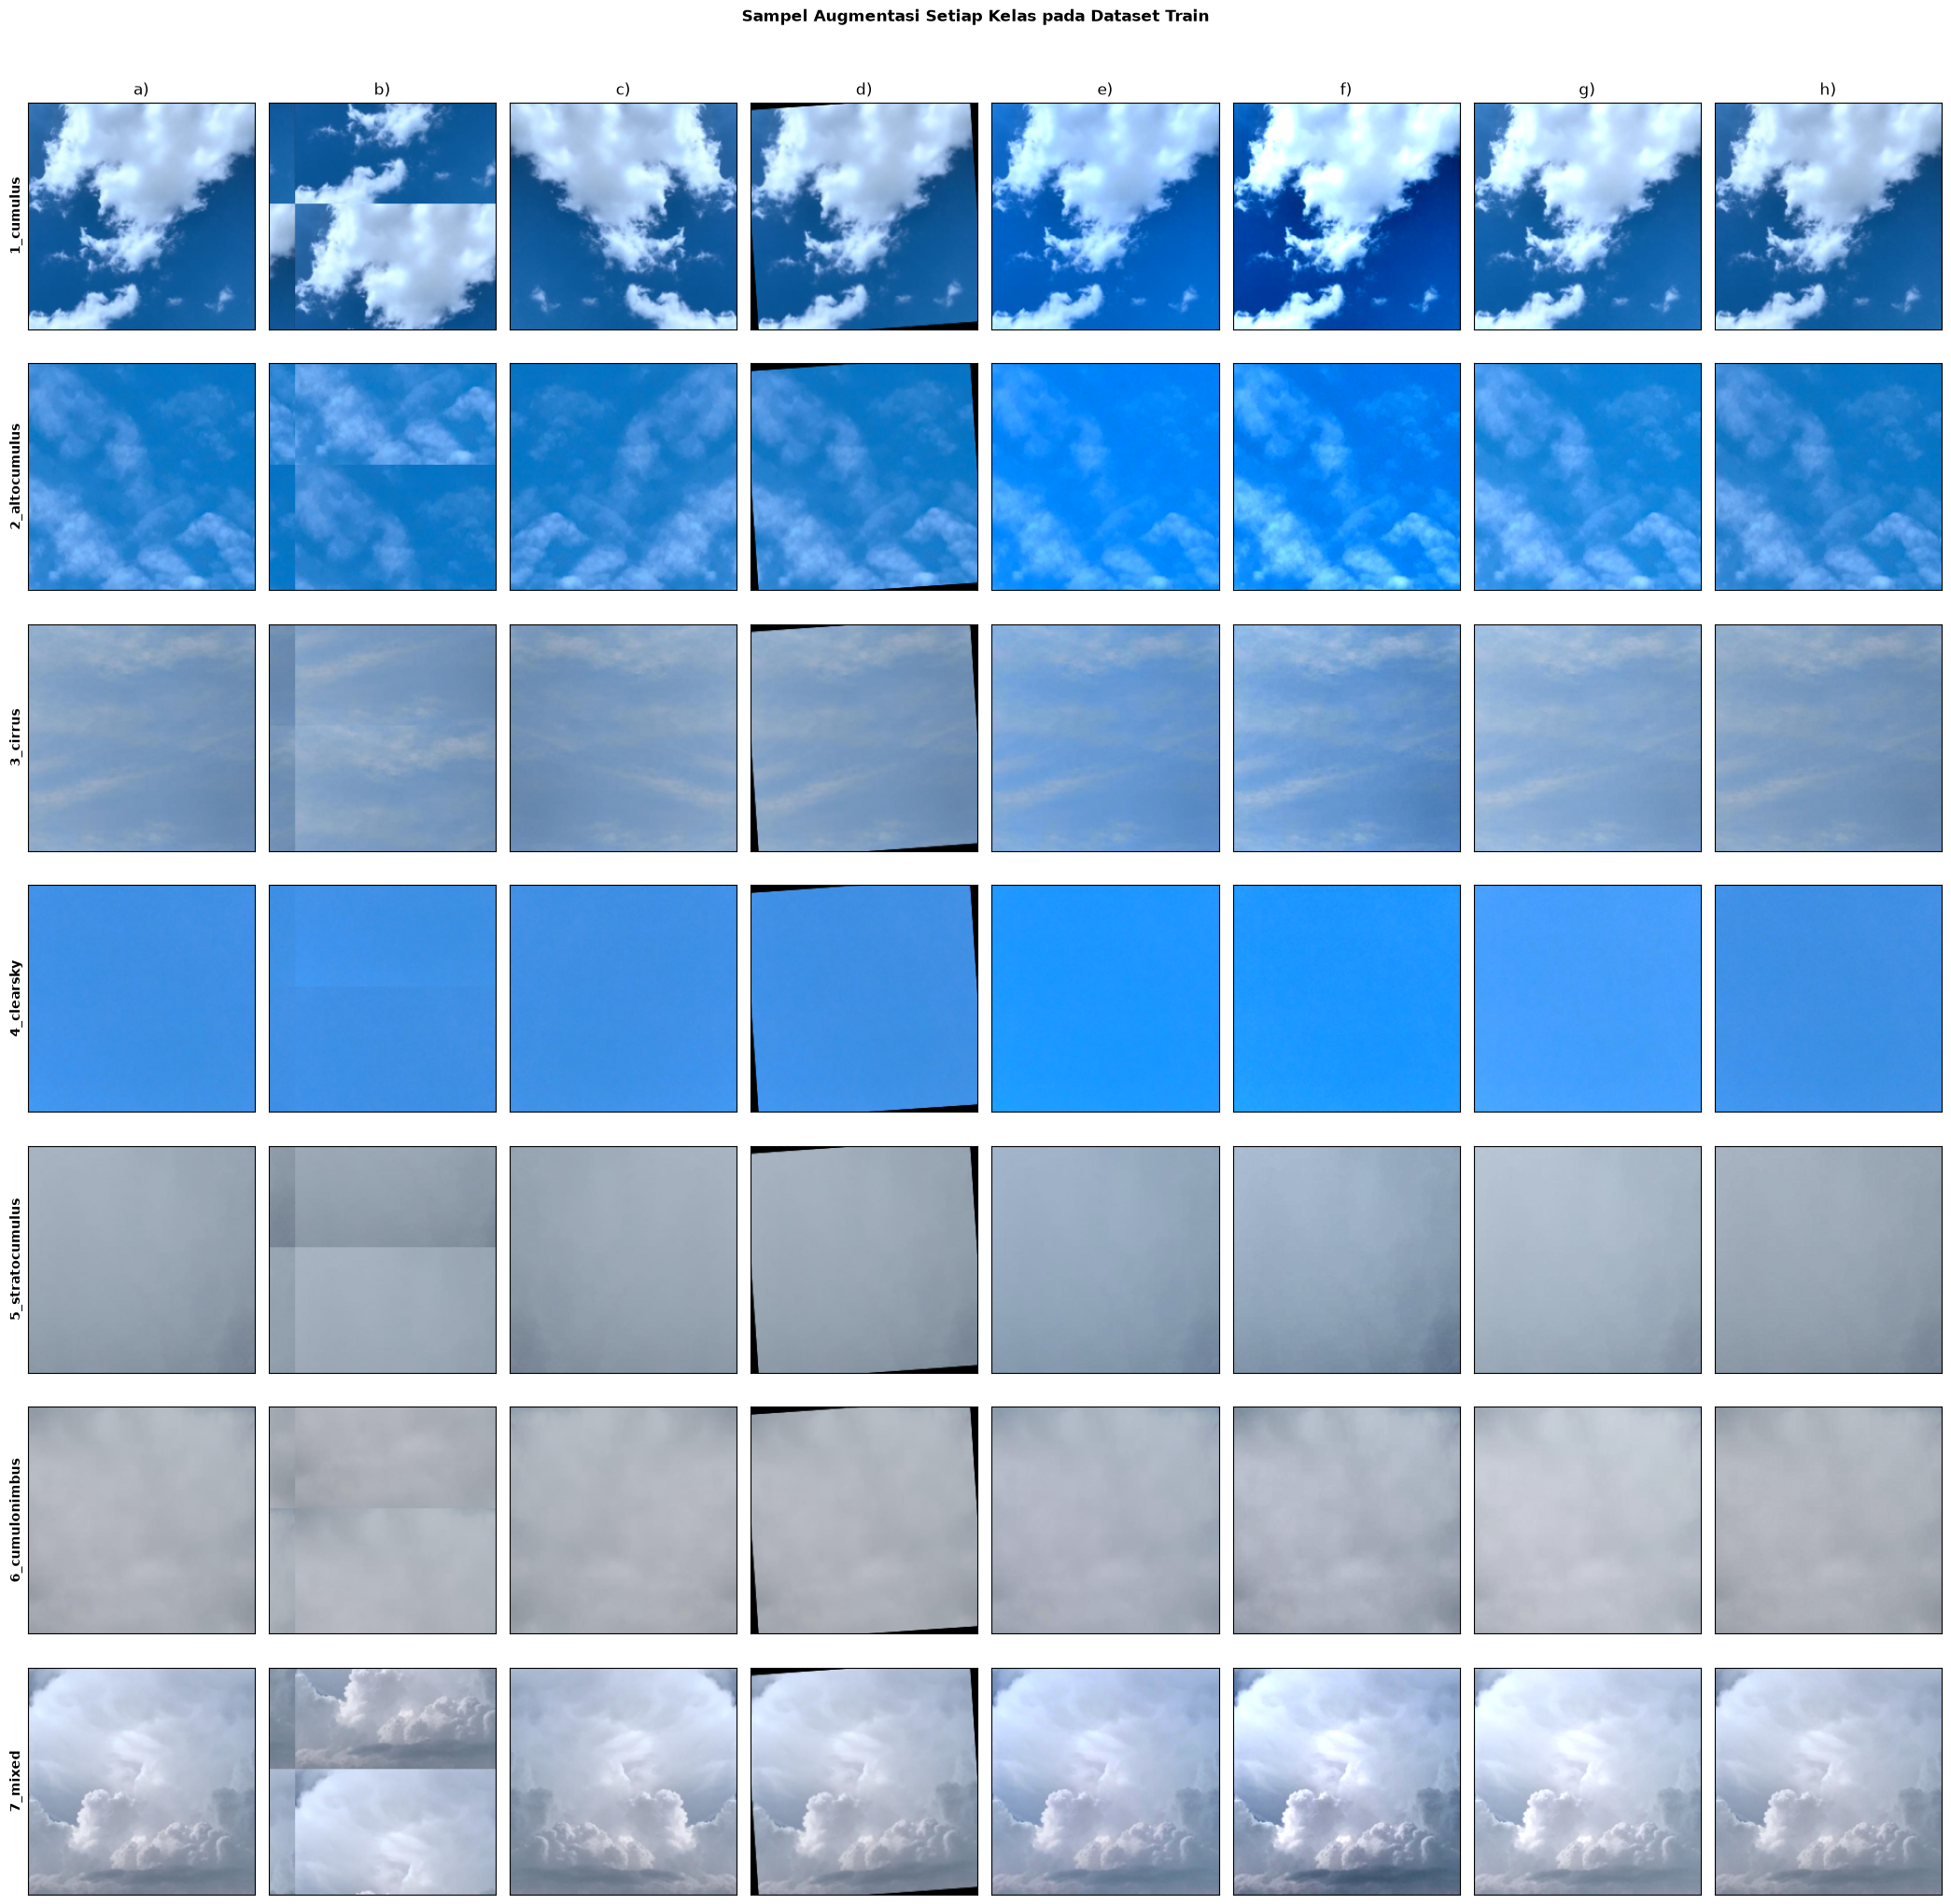

In [46]:
number_of_classes = len(sample_images)
number_of_transformations = len(augmentations)
fig, axes = plt.subplots(
    nrows=number_of_classes,
    ncols=number_of_transformations,
    figsize=(21, 3 * number_of_classes),
    squeeze=False,
)

for row_index, (class_name, image_path) in enumerate(sample_images.items()):
    with Image.open(image_path) as original_image:
        image_tensor = prepare_image(original_image.convert("RGB"))
    for column_index, (title, transformation) in enumerate(augmentations.items()):
        transformed_image = transformation(image_tensor.clone()).clamp(0, 1)
        axes[row_index, column_index].imshow(
            transformed_image.permute(1, 2, 0).cpu().numpy()
        )
        if row_index == 0:
            axes[row_index, column_index].set_title(title)
        if column_index == 0:
            axes[row_index, column_index].set_ylabel(class_name, fontweight="bold")
        axes[row_index, column_index].set_xticks([])
        axes[row_index, column_index].set_yticks([])

fig.suptitle("Sampel Augmentasi Setiap Kelas pada Dataset Train", fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(LOG_DIR / "sampel_augmentasi.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [49]:
# Jumlah akhir mengikuti banyaknya citra asli, bukan target per kelas.
number_of_augmentations = len(AUGMENTATION_LABELS)
plan_rows = []
for class_name, paths in train_originals.items():
    original_count = len(paths)
    plan_rows.append({
        "Nama Kelas": class_name,
        "Train Asli": original_count,
        "Variasi per Citra": number_of_augmentations,
        "Tambahan Direncanakan": original_count * number_of_augmentations,
        "Train Akhir Direncanakan": original_count * (1 + number_of_augmentations),
    })
plan_df = pd.DataFrame(plan_rows)
display(plan_df)
expected_total = int(plan_df["Train Akhir Direncanakan"].sum())
print(f"Total train yang diharapkan: {expected_total:,}")
print("Jumlah tiap kelas mengikuti data aslinya; tidak ada batas tetap.")

,Nama Kelas,Train Asli,Variasi per Citra,Tambahan Direncanakan,Train Akhir Direncanakan
0,1_cumulus,698,7,4886,5584
1,2_altocumulus,653,7,4571,5224
2,3_cirrus,1038,7,7266,8304
3,4_clearsky,1935,7,13545,15480
4,5_stratocumulus,1662,7,11634,13296
5,6_cumulonimbus,2703,7,18921,21624
6,7_mixed,314,7,2198,2512


Total train yang diharapkan: 72,024
Jumlah tiap kelas mengikuti data aslinya; tidak ada batas tetap.


In [47]:
# Daftar yang sama dipakai untuk perencanaan, pembuatan, dan verifikasi.
augmentation_labels = list(AUGMENTATION_LABELS)
to_pil_image = T.ToPILImage()
if not set(augmentation_labels).issubset(augmentations):
    raise ValueError("Ada transformasi aktif yang belum didefinisikan.")

In [48]:
augmentation_summary = []
augmentation_records = []

# Memproses SETIAP citra train asli, tanpa random.sample atau pemangkasan.
for class_name, image_paths in train_originals.items():
    augmentation_count = 0
    print(f"Memproses {class_name}: {len(image_paths):,} citra asli...")
    for source_index, source_path in enumerate(image_paths, start=1):
        with Image.open(source_path) as image:
            image_tensor = prepare_image(image.convert("RGB"))

        # Setiap transformasi dimulai dari tensor asli, bukan hasil sebelumnya.
        for augmentation_label in augmentation_labels:
            augmented_tensor = augmentations[augmentation_label](
                image_tensor.clone()
            ).clamp(0, 1)
            augmented_image = to_pil_image(augmented_tensor)
            output_path = augmentation_path(source_path, augmentation_label)
            if output_path not in expected_augmented_paths:
                raise RuntimeError("Rencana berubah; jalankan kembali notebook dari sel pertama.")
            augmented_image.save(
                output_path, format="JPEG", quality=AUGMENTATION_PARAMS["jpeg_quality"]
            )
            augmentation_count += 1
            augmentation_records.append({
                "kelas": class_name,
                "sumber_train_asli": source_path.relative_to(PROJECT_DIR).as_posix(),
                "sumber_mentah": original_sources[source_path].relative_to(PROJECT_DIR).as_posix(),
                "transformasi": augmentation_label,
                "hasil_augmentasi": output_path.relative_to(PROJECT_DIR).as_posix(),
            })

        if source_index % 250 == 0:
            print(f"  {source_index:,}/{len(image_paths):,} citra asli selesai")

    actual_count = len(list_images(TRAIN_DIR / class_name))
    augmentation_summary.append({
        "Nama Kelas": class_name,
        "Train Asli": len(image_paths),
        "Augmentasi": augmentation_count,
        "Train Akhir Diharapkan": len(image_paths) * (1 + len(augmentation_labels)),
        "Train Akhir Aktual": actual_count,
    })
    print(f"{class_name}: asli={len(image_paths):,}, tambahan={augmentation_count:,}, akhir={actual_count:,}")

Memproses 1_cumulus: 698 citra asli...
  250/698 citra asli selesai
  500/698 citra asli selesai
1_cumulus: asli=698, tambahan=4,886, akhir=5,584
Memproses 2_altocumulus: 653 citra asli...
  250/653 citra asli selesai
  500/653 citra asli selesai
2_altocumulus: asli=653, tambahan=4,571, akhir=5,224
Memproses 3_cirrus: 1,038 citra asli...
  250/1,038 citra asli selesai
  500/1,038 citra asli selesai
  750/1,038 citra asli selesai
  1,000/1,038 citra asli selesai
3_cirrus: asli=1,038, tambahan=7,266, akhir=8,304
Memproses 4_clearsky: 1,935 citra asli...
  250/1,935 citra asli selesai
  500/1,935 citra asli selesai
  750/1,935 citra asli selesai
  1,000/1,935 citra asli selesai
  1,250/1,935 citra asli selesai
  1,500/1,935 citra asli selesai
  1,750/1,935 citra asli selesai
4_clearsky: asli=1,935, tambahan=13,545, akhir=15,480
Memproses 5_stratocumulus: 1,662 citra asli...
  250/1,662 citra asli selesai
  500/1,662 citra asli selesai
  750/1,662 citra asli selesai
  1,000/1,662 citra asl

In [50]:
# Memeriksa file nyata dan asal sumber, bukan hanya angka pada ringkasan.
summary_df = pd.DataFrame(augmentation_summary)
if summary_df.empty:
    raise RuntimeError("Ringkasan kosong. Jalankan sel augmentasi terlebih dahulu.")

expected_train_paths = {
    path for paths in train_originals.values() for path in paths
} | expected_augmented_paths
actual_train_paths = set(list_images(TRAIN_DIR))
assert actual_train_paths == expected_train_paths, "Isi folder train tidak sesuai rencana."

assert (
    summary_df["Train Akhir Aktual"] == summary_df["Train Akhir Diharapkan"]
).all(), "Jumlah akhir salah pada satu atau beberapa kelas."
assert (
    summary_df["Augmentasi"] == summary_df["Train Asli"] * len(augmentation_labels)
).all(), "Ada citra yang belum memperoleh seluruh variasi."
assert len(augmentation_records) == len(expected_augmented_paths), "Catatan augmentasi tidak lengkap."

# Validation dan test hanya boleh memuat salinan citra asli yang direncanakan.
for split in ("val", "test"):
    expected_paths = {
        path for paths in originals_by_split[split].values() for path in paths
    }
    assert set(list_images(OUTPUT_DIR / split)) == expected_paths, f"Isi {split} berubah."

# Memastikan data mentah dan semua salinan asli tetap sama secara byte.
for destination, raw_path in original_sources.items():
    assert file_sha256(raw_path) == raw_hashes[raw_path], f"Data mentah berubah: {raw_path}"
    assert file_sha256(destination) == raw_hashes[raw_path], f"Salinan asli berubah: {destination}"

actual_total = len(actual_train_paths)
assert actual_total == expected_total, "Total train aktual tidak sesuai perencanaan."
display(summary_df)
print(f"Verifikasi berhasil. Train asli: {jumlah_file_train:,}")
print(f"Augmentasi: {len(augmentation_records):,}; total train: {actual_total:,}")
print(f"Validation: {jumlah_file_val:,}; test resmi: {jumlah_file_test:,}")
print("Semua citra asli terjaga dan augmentasi hanya bersumber dari train asli.")

,Nama Kelas,Train Asli,Augmentasi,Train Akhir Diharapkan,Train Akhir Aktual
0,1_cumulus,698,4886,5584,5584
1,2_altocumulus,653,4571,5224,5224
2,3_cirrus,1038,7266,8304,8304
3,4_clearsky,1935,13545,15480,15480
4,5_stratocumulus,1662,11634,13296,13296
5,6_cumulonimbus,2703,18921,21624,21624
6,7_mixed,314,2198,2512,2512


Verifikasi berhasil. Train asli: 9,003
Augmentasi: 63,021; total train: 72,024
Validation: 997; test resmi: 9,000
Semua citra asli terjaga dan augmentasi hanya bersumber dari train asli.


In [51]:
# Catat hasil aktual dan parameter agar eksperimen dapat ditelusuri.
json_log_data_aug = {
    "metode": "seluruh_citra_train_dengan_semua_transformasi_aktif",
    "seed": SEED,
    "batas_tetap_per_kelas": None,
    "penyeimbangan_antar_kelas": False,
    "transformasi_aktif": augmentation_labels,
    "parameter": AUGMENTATION_PARAMS,
    "ukuran_augmentasi": list(IMAGE_SIZE),
    "total_train_asli": jumlah_file_train,
    "total_augmentasi": len(augmentation_records),
    "total_train_akhir": actual_total,
    "total_validation": jumlah_file_val,
    "total_test_resmi": jumlah_file_test,
    "verifikasi_citra_asli": "SHA-256 sama",
    "rincian_per_kelas": summary_df.to_dict(orient="records"),
}

In [ ]:
with (LOG_DIR / "dataset_setelah_augmentasi.json").open("w", encoding="utf-8") as handle:
    json.dump(json_log_data_aug, handle, indent=2, ensure_ascii=False)
summary_df.to_csv(LOG_DIR / "dataset_setelah_augmentasi.csv", index=False)
pd.DataFrame(augmentation_records).to_csv(
    LOG_DIR / "data_augmentation_manifest.csv", index=False
)
print("Ringkasan akhir dan catatan asal setiap hasil augmentasi berhasil disimpan.")
print(f"Lokasi metadata: {LOG_DIR}")
print(f"Lokasi contoh visual: {LOG_DIR / 'sampel_augmentasi.png'}")

Ringkasan akhir dan catatan asal setiap hasil augmentasi berhasil disimpan.
Lokasi metadata: d:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\logs
Lokasi contoh visual: d:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\logs\sampel_augmentasi.png


: 